In [26]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
import os
from PIL import Image

source = "/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages"
cleaned = "/kaggle/working/PetImages_clean"

os.makedirs(cleaned, exist_ok=True)

bad_files = []
converted = 0

for class_name in os.listdir(source):

    source_class = os.path.join(source, class_name)
    cleaned_class = os.path.join(cleaned, class_name)

    if not os.path.isdir(source_class):
        continue

    os.makedirs(cleaned_class, exist_ok=True)

    for filename in os.listdir(source_class):

        source_path = os.path.join(source_class, filename)
        cleaned_path = os.path.join(cleaned_class, filename)

        try:
            img = Image.open(source_path)

            # Convert every image to RGB
            if img.mode != "RGB":
                converted += 1

            img = img.convert("RGB")
            img.save(cleaned_path)

        except Exception as e:
            bad_files.append((source_path, str(e)))

print("Images converted:", converted)
print("Bad images:", len(bad_files))

for file in bad_files[:20]:
    print(file)

Images converted: 67
Bad images: 0


In [4]:
dataset_path = "/kaggle/working/PetImages_clean"

In [5]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense , Conv2D , MaxPooling2D , Flatten , BatchNormalization , Dropout
from keras.applications.vgg16 import VGG16

In [6]:
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape= (150 , 150 , 3)
)

I0000 00:00:1789493582.622308      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789493582.625287      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256 , activation='relu'))
model.add(Dense(1 , activation = 'sigmoid'))

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
conv_base.trainable = False

In [13]:
#generators
data = keras.utils.image_dataset_from_directory(
    directory = dataset_path,
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256 , 256),
)

Found 24998 files belonging to 2 classes.


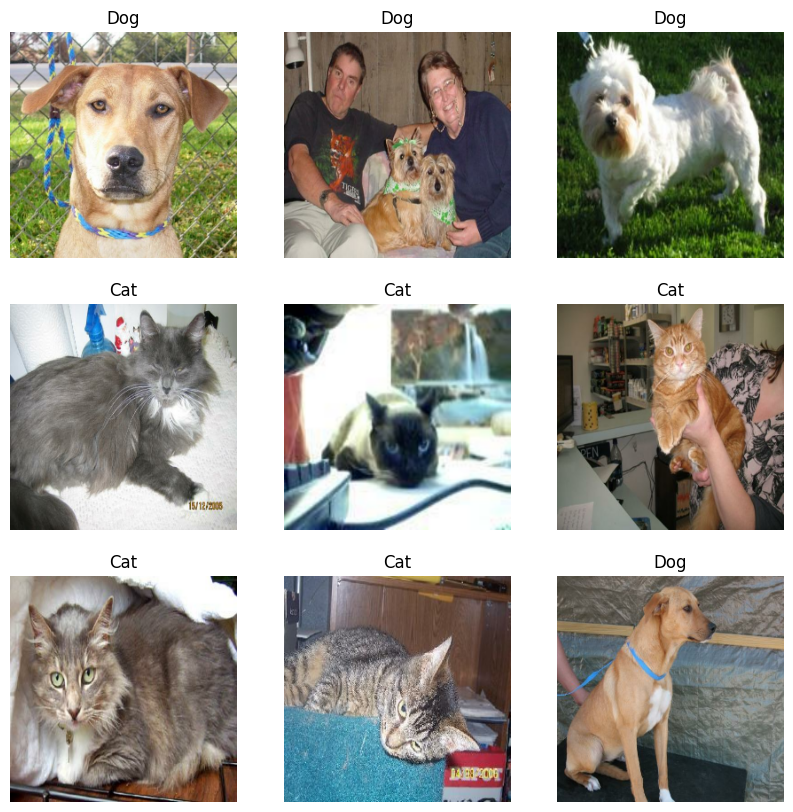

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(data.class_names[labels[i]])
        plt.axis("off")

In [19]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (150 , 150)
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (150 , 150)
)

Found 24998 files belonging to 2 classes.
Found 24998 files belonging to 2 classes.


In [20]:
#Normalize

def process(image , label):
    image = tf.cast(image/255. , tf.float32)
    return image , label

train_ds = train_ds.map(process)
val_ds = val_ds.map(process)

In [21]:
model.compile(optimizer = 'adam' , loss='binary_crossentropy' , metrics=['accuracy'])

In [22]:
history = model.fit(train_ds , epochs=15 , validation_data = val_ds)

Epoch 1/15
  2/782 ━━━━━━━━━━━━━━━━━━━━ 1:15 97ms/step - accuracy: 0.5234 - loss: 1.2574 

I0000 00:00:1789494211.269010     285 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 169s 204ms/step - accuracy: 0.8906 - loss: 0.2559 - val_accuracy: 0.9165 - val_loss: 0.1970
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 156s 200ms/step - accuracy: 0.9216 - loss: 0.1894 - val_accuracy: 0.9394 - val_loss: 0.1476
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 160s 205ms/step - accuracy: 0.9363 - loss: 0.1553 - val_accuracy: 0.8928 - val_loss: 0.2485
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 156s 200ms/step - accuracy: 0.9435 - loss: 0.1398 - val_accuracy: 0.9500 - val_loss: 0.1228
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 156s 199ms/step - accuracy: 0.9583 - loss: 0.1048 - val_accuracy: 0.9575 - val_loss: 0.1040
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 156s 200ms/step - accuracy: 0.9678 - loss: 0.0841 - val_accuracy: 0.9667 - val_loss: 0.0836
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 156s 199ms/step - accuracy: 0.9748 - loss: 0.0644 - val_accuracy: 0.9638 - val_loss: 0.0904
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 156s 200ms/step - accuracy: 0.9808 - loss: 0.05

In [23]:
print("Final Training Accuracy:", history.history["accuracy"][-1])
print("Final Training Loss:", history.history["loss"][-1])

print("Final Validation Accuracy:", history.history["val_accuracy"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

Final Training Accuracy: 0.9941195249557495
Final Training Loss: 0.017345808446407318
Final Validation Accuracy: 0.9823985695838928
Final Validation Loss: 0.04596130922436714


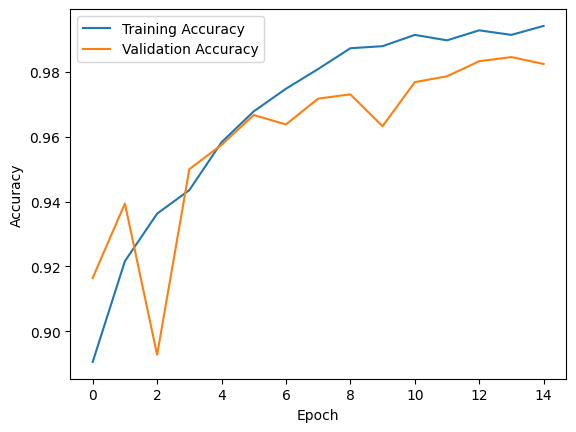

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

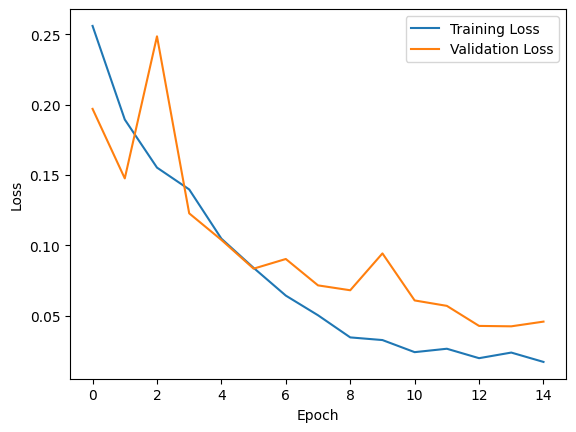

In [25]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()